# 14 Optuna 하이퍼파라미터 튜닝 (LSTM + 시계열 임베딩)

10장의 **대표(메인) 예측 모델 = LSTM + 시계열 임베딩(static exog)** 을 type별로 **Optuna(TPE)** 로 튜닝해, 검증 13주 **MAPE**를 개선할 수 있는지 확인합니다.

## 왜 하는가
- 본 실습의 메인 하이브리드 모델은 **LSTM + 임베딩** (Phase2, 10~11장) → 이 모델을 직접 튜닝
- **Optuna(TPE)** 로 `input_size(lookback)·encoder_hidden_size·encoder_n_layers·learning_rate·max_steps` 자동 탐색
- 튜닝 전·후 검증 MAPE 비교로 **type별 개선 여지** 정량화

| 항목 | 내용 |
|------|------|
| 모델 | **LSTM + 임베딩** (neuralforecast, 임베딩=PCA static exog) |
| 목적함수 | 검증 13주 **평균 family MAPE** 최소화 |
| 탐색 | `input_size`, `encoder_hidden_size`, `encoder_n_layers`, `learning_rate`, `max_steps` |
| 단위 | type 2개(E·C) 각각 독립 |

**선행:** 02, 03, 06, 10 | **산출:** `lstm_optuna_tuning_results.csv`

### ⓪ 환경 설정 · type별 입력 준비

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'code' else NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'code'))

from utils.paths import DATA_PROCESSED
from utils.splits import TRAIN_WEEK_MAX, VAL_WEEKS
from utils.device import device_label
from utils.experiment_data import load_forecast_frames
from utils.dl_models import condition_wide
from utils.embeddings import embed_pca
from utils.phase_experiments import _fit_embedding
from utils.tuning import lstm_embedding_val_mape, tune_lstm_embedding_type
from utils.config import selected_type_list

N_TRIALS = 12  # type당 Optuna trial 수 (LSTM 학습이라 과도히 늘리면 시간↑)
H = len(VAL_WEEKS)

df, feat_df = load_forecast_frames()
types = selected_type_list()
print('Torch device:', device_label())
print('대표 모델: LSTM + 시계열 임베딩(PCA static exog)')
print('types:', types, '| 학습 <=', TRAIN_WEEK_MAX, '| 검증(튜닝):', VAL_WEEKS, '| n_trials:', N_TRIALS)

def type_inputs(typ):
    sub = df[df['type'] == typ]
    keys = list(sub[['type', 'family']].drop_duplicates().itertuples(index=False, name=None))
    mat = np.vstack([
        sub[(sub['family'] == f) & (sub['yearweek'] <= TRAIN_WEEK_MAX)]['sales'].values
        for _, f in keys
    ]).astype(float)
    emb = _fit_embedding(mat, embed_pca)
    emb_map = {f: emb[i] for i, (_, f) in enumerate(keys)}
    wide = condition_wide(sub[sub['yearweek'] <= TRAIN_WEEK_MAX])
    val_actual = {
        f: sub[(sub['family'] == f) & (sub['yearweek'].isin(VAL_WEEKS))].sort_values('yearweek')['sales'].to_numpy(float)
        for _, f in keys
    }
    return wide, emb_map, val_actual

inputs = {t: type_inputs(t) for t in types}
print('입력 준비 완료:', {t: inputs[t][0].shape for t in types})

Torch device: cuda (NVIDIA GeForce RTX 5090, 32GB)
대표 모델: LSTM + 시계열 임베딩(PCA static exog)
types: ['E', 'C'] | 학습 <= 201707 | 검증(튜닝): [201708, 201709, 201710, 201711, 201712, 201713, 201714, 201715, 201716, 201717, 201718, 201719, 201720] | n_trials: 12
입력 준비 완료: {'E': (216, 33), 'C': (216, 33)}


### ① baseline MAPE (튜닝 전 기본 LSTM+임베딩)

In [2]:
baseline_rows = []
for t in types:
    wide, emb_map, val_actual = inputs[t]
    m = lstm_embedding_val_mape(wide, emb_map, val_actual, H, None)
    baseline_rows.append({'type': t, 'baseline_mape': round(m, 4)})
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.to_string(index=False))

Seed set to 42


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


You are using a CUDA device ('NVIDIA GeForce RTX 5090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

`Trainer.fit` stopped: `max_steps=300` reached.


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


type  baseline_mape
   E        31.3763
   C        18.5348


### ② Optuna 튜닝 — type별 검증 MAPE 최소화

type마다 독립 study. LSTM+임베딩을 학습 구간에 학습하고 **검증 13주 평균 family MAPE**를 목적함수로 사용합니다.

In [3]:
results_rows = []
for _, r in baseline_df.iterrows():
    t = r['type']
    base = float(r['baseline_mape'])
    wide, emb_map, val_actual = inputs[t]
    best_params, tuned = tune_lstm_embedding_type(wide, emb_map, val_actual, H, n_trials=N_TRIALS)
    imp = (base - tuned) / base * 100 if base else float('nan')
    results_rows.append({
        'type': t, 'baseline_mape': round(base, 4), 'tuned_mape': round(tuned, 4),
        'improvement_pct': round(imp, 2), 'n_trials': N_TRIALS,
        **{f'best_{k}': v for k, v in best_params.items()},
    })
results = pd.DataFrame(results_rows)
display(results)

Seed set to 42


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 19.7 K | train
4 | mlp_decoder  | MLP           | 8.4 K  | train
-------------------------------------------------------
28.2 K    Trainable params
0         Non-trainable params
28.2 K    Total params
0.113     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


...

`Trainer.fit` stopped: `max_steps=400` reached.


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


,type,baseline_mape,tuned_mape,improvement_pct,n_trials,best_input_size,best_encoder_hidden_size,best_encoder_n_layers,best_learning_rate,best_max_steps
0,E,31.3763,31.2581,0.38,12,26,64,1,0.005399,400
1,C,18.5348,16.5718,10.59,12,13,256,2,0.000731,400


### ③ baseline vs tuned 비교

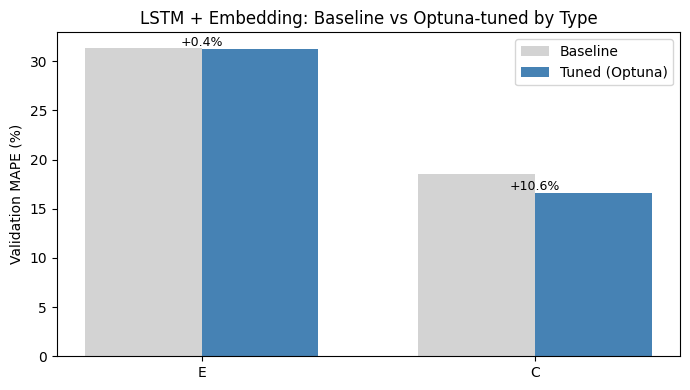

type  baseline_mape  tuned_mape  improvement_pct
   E        31.3763     31.2581             0.38
   C        18.5348     16.5718            10.59


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(results)); w = 0.35
ax.bar(x - w/2, results['baseline_mape'], w, label='Baseline', color='lightgray')
ax.bar(x + w/2, results['tuned_mape'], w, label='Tuned (Optuna)', color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(results['type'])
ax.set_ylabel('Validation MAPE (%)')
ax.set_title('LSTM + Embedding: Baseline vs Optuna-tuned by Type')
ax.legend()
for i, row in results.iterrows():
    if pd.notna(row['improvement_pct']):
        ax.annotate(f"{row['improvement_pct']:+.1f}%", (i, row['tuned_mape']), ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print(results[['type', 'baseline_mape', 'tuned_mape', 'improvement_pct']].to_string(index=False))

### ④ type별 Best 하이퍼파라미터

In [5]:
param_cols = [c for c in results.columns if c.startswith('best_')]
best_params = results[['type'] + param_cols].copy()
best_params.columns = ['type'] + [c.replace('best_', '') for c in param_cols]
display(best_params)

,type,input_size,encoder_hidden_size,encoder_n_layers,learning_rate,max_steps
0,E,26,64,1,0.005399,400
1,C,13,256,2,0.000731,400


### ⑤ 해석 가이드

- **improvement_pct > 0** → 해당 type에서 튜닝이 검증 MAPE를 개선
- `input_size`(lookback)·`encoder_hidden_size`가 type마다 다르면 → **매장 유형별 맞춤 LSTM** 근거
- 개선이 작으면 → 기본 설정이 이미 충분하거나 13주 검증이 짧아 과적합 여지

> 단일 validation window 기준입니다. 운영 전에는 rolling CV 등으로 재검증하세요.

In [6]:
results.to_csv(DATA_PROCESSED / 'lstm_optuna_tuning_results.csv', index=False)
best_only = results[['type'] + param_cols].rename(columns={c: c.replace('best_', '') for c in param_cols})
best_only.to_csv(DATA_PROCESSED / 'lstm_optuna_best_params_by_type.csv', index=False)
print('저장:', DATA_PROCESSED / 'lstm_optuna_tuning_results.csv')

저장: C:\Users\kjh\ai-retail-demandforecasting\data\processed\lstm_optuna_tuning_results.csv
